# Porto Seguro's Safe Driver Prediction

**Projekt SoSe 2026 — Scientific Programming And Data Analysis / Advanced Data Analytics**

## Ziel
Vorhersage der Wahrscheinlichkeit, dass eine Kundin Ansprüche wegen einer Schadensregulierung gegenüber dem brasilianischen Autoversicherer Porto Seguro erhebt, basierend auf anonymisierten Kundendaten.

## Ablauf des Notebooks
1. Import der Bibliotheken
2. Laden der Daten (über OpenML)
3. Explorative Datenanalyse (EDA)
4. Datenvorverarbeitung (Bereinigung, fehlende Werte, Encoding)
5. Aufteilung in Trainings- und Testdaten
6. Baseline-Modell: Logistische Regression
7. Hauptmodell: LightGBM (Gradient Boosting)
8. Evaluation (Normalisierter Gini-Koeffizient / AUC-ROC)
9. Feature Importance
10. Fazit

## 1. Import der Bibliotheken

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

pd.set_option('display.max_columns', 100)
sns.set_style("whitegrid")

RANDOM_STATE = 42

## 2. Laden der Daten

Der Datensatz ist auf OpenML unter der ID `42742` verfügbar. Wir verwenden `fetch_openml` von Scikit-Learn, um ihn direkt herunterzuladen.

In [33]:
# Herunterladen des Datensatzes von OpenML (ID = 42742)
data = fetch_openml(data_id=42742, as_frame=True, parser='auto')

df = data.frame
print("Dimensionen des Datensatzes:", df.shape)
df.head()

Dimensionen des Datensatzes: (595212, 58)


,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,0,2.0,2,5.0,1,0,0,1,0,0,0,0,0,0,0.0,11.0,0,1,0,0.7,0.2,0.718070,10,1,NaN,0,1,4,1,0,0,1,12,2.0,0.400000,0.883679,0.370810,3.605551,0.6,0.5,0.2,3.0,1.0,10.0,1.0,10.0,1.0,5.0,9.0,1.0,5.0,8.0,0,1,1,0,0,1
1,0,1.0,1,7.0,0,0,0,0,1,0,0,0,0,0,0.0,3.0,0,0,1,0.8,0.4,0.766078,11,1,NaN,0,NaN,11,1,1,2,1,19,3.0,0.316228,0.618817,0.388716,2.449490,0.3,0.1,0.3,2.0,1.0,9.0,5.0,8.0,1.0,7.0,3.0,1.0,1.0,9.0,0,1,1,0,1,0
2,0,5.0,4,9.0,1,0,0,0,1,0,0,0,0,0,0.0,12.0,1,0,0,0.0,0.0,NaN,7,1,NaN,0,NaN,14,1,1,2,1,60,1.0,0.316228,0.641586,0.347275,3.316625,0.5,0.7,0.1,2.0,2.0,9.0,1.0,8.0,2.0,7.0,4.0,2.0,7.0,7.0,0,1,1,0,1,0
3,0,0.0,1,2.0,0,0,1,0,0,0,0,0,0,0,0.0,8.0,1,0,0,0.9,0.2,0.580948,7,1,0,0,1,11,1,1,3,1,104,1.0,0.374166,0.542949,0.294958,2.000000,0.6,0.9,0.1,2.0,4.0,7.0,1.0,8.0,4.0,2.0,2.0,2.0,4.0,9.0,0,0,0,0,0,0
4,0,0.0,2,0.0,1,0,1,0,0,0,0,0,0,0,0.0,9.0,1,0,0,0.7,0.6,0.840759,11,1,NaN,0,NaN,14,1,1,2,1,82,3.0,0.316070,0.565832,0.365103,2.000000,0.4,0.6,0.0,2.0,2.0,6.0,3.0,10.0,2.0,12.0,3.0,1.0,1.0,3.0,0,0,0,1,1,0


## 3. Explorative Datenanalyse (EDA)

### 3.1 Allgemeine Informationen

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 58 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   target          595212 non-null  category
 1   ps_ind_01       595212 non-null  float64 
 2   ps_ind_02_cat   594996 non-null  category
 3   ps_ind_03       595212 non-null  float64 
 4   ps_ind_04_cat   595129 non-null  category
 5   ps_ind_05_cat   589403 non-null  category
 6   ps_ind_06_bin   595212 non-null  category
 7   ps_ind_07_bin   595212 non-null  category
 8   ps_ind_08_bin   595212 non-null  category
 9   ps_ind_09_bin   595212 non-null  category
 10  ps_ind_10_bin   595212 non-null  category
 11  ps_ind_11_bin   595212 non-null  category
 12  ps_ind_12_bin   595212 non-null  category
 13  ps_ind_13_bin   595212 non-null  category
 14  ps_ind_14       595212 non-null  float64 
 15  ps_ind_15       595212 non-null  float64 
 16  ps_ind_16_bin   595212 non-null  categ

In [35]:
# Identifikation der Zielvariable
# Bei OpenML heißt die Zielvariable in der Regel "target"
target_col = "target"
print(df[target_col].value_counts())
print("\nAnteil der Schadensfälle (Klasse 1):", df[target_col].value_counts(normalize=True)[1])

target
0    573518
1     21694
Name: count, dtype: int64

Anteil der Schadensfälle (Klasse 1): 0.036447517859182946


C:\Users\Ich\AppData\Local\Temp\ipykernel_20580\2213109899.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("\nAnteil der Schadensfälle (Klasse 1):", df[target_col].value_counts(normalize=True)[1])


### 3.2 Klassenungleichgewicht

Wir visualisieren das Ungleichgewicht zwischen Kundinnen, die einen Anspruch erheben (`target=1`), und solchen, die keinen erheben (`target=0`).

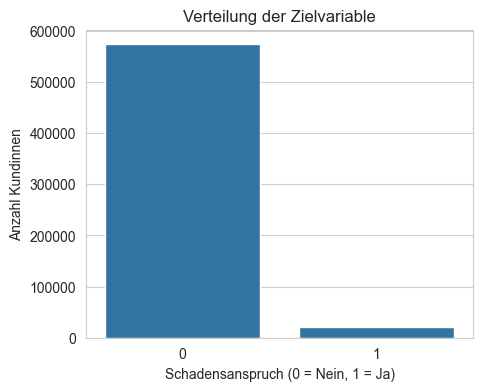

In [36]:
plt.figure(figsize=(5,4))
sns.countplot(x=target_col, data=df)
plt.title("Verteilung der Zielvariable")
plt.xlabel("Schadensanspruch (0 = Nein, 1 = Ja)")
plt.ylabel("Anzahl Kundinnen")
plt.show()

### 3.3 Fehlende Werte

In diesem Datensatz sind fehlende Werte mit `-1` kodiert (nicht mit `NaN`). Wir identifizieren sie spaltenweise.

In [37]:
# Zählung der -1-Werte (= fehlende Werte) pro Spalte
missing_counts = (df == -1).sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]
missing_pct = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({'nb_manquantes': missing_counts, 'pct_manquantes': missing_pct})
missing_summary

,nb_manquantes,pct_manquantes


### 3.4 Variablentypen

Die Spalten folgen einer Namenskonvention:
- `_bin` → binäre Variable
- `_cat` → kategoriale Variable
- kein Suffix → kontinuierliche oder ordinale Variable

In [38]:
bin_cols = [c for c in df.columns if c.endswith('_bin')]
cat_cols = [c for c in df.columns if c.endswith('_cat')]
other_cols = [c for c in df.columns if c not in bin_cols + cat_cols + [target_col, 'id']]

print(f"Binäre Variablen ({len(bin_cols)}):", bin_cols)
print(f"\nKategoriale Variablen ({len(cat_cols)}):", cat_cols)
print(f"\nAndere Variablen ({len(other_cols)}):", other_cols)

Binäre Variablen (17): ['ps_ind_06_bin', 'ps_ind_07_bin', 'ps_ind_08_bin', 'ps_ind_09_bin', 'ps_ind_10_bin', 'ps_ind_11_bin', 'ps_ind_12_bin', 'ps_ind_13_bin', 'ps_ind_16_bin', 'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_calc_15_bin', 'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin', 'ps_calc_19_bin', 'ps_calc_20_bin']

Kategoriale Variablen (14): ['ps_ind_02_cat', 'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat', 'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat', 'ps_car_10_cat', 'ps_car_11_cat']

Andere Variablen (26): ['ps_ind_01', 'ps_ind_03', 'ps_ind_14', 'ps_ind_15', 'ps_reg_01', 'ps_reg_02', 'ps_reg_03', 'ps_car_11', 'ps_car_12', 'ps_car_13', 'ps_car_14', 'ps_car_15', 'ps_calc_01', 'ps_calc_02', 'ps_calc_03', 'ps_calc_04', 'ps_calc_05', 'ps_calc_06', 'ps_calc_07', 'ps_calc_08', 'ps_calc_09', 'ps_calc_10', 'ps_calc_11', 'ps_calc_12', 'ps_calc_13', 'ps_calc_14']


### 3.5 Korrelation der Variablen mit der Zielvariable

Als Teil der explorativen Analyse betrachten wir die (lineare) Korrelation jeder Variable mit der Zielvariable `target`. Dies gibt einen ersten Hinweis darauf, welche Variablen möglicherweise wenig prädiktive Kraft besitzen — unabhängig von einem späteren Modell.

In [65]:
all_feature_cols = [c for c in other_cols + bin_cols if c in df.columns]

corr_with_target = df[all_feature_cols].apply(lambda col: col.astype(float).corr(df[target_col].astype(float)))
corr_with_target = corr_with_target.abs().sort_values(ascending=True)

print("Die 15 Variablen mit der NIEDRIGSTEN |Korrelation| zur Zielvariable:")
print(corr_with_target.head(15))
print("\nZum Vergleich, die 10 Variablen mit der HÖCHSTEN |Korrelation|:")
print(corr_with_target.tail(10))

Die 15 Variablen mit der NIEDRIGSTEN |Korrelation| zur Zielvariable:
ps_calc_04        0.000033
ps_calc_06        0.000082
ps_calc_07        0.000103
ps_calc_17_bin    0.000170
ps_calc_11        0.000371
ps_calc_13        0.000446
ps_calc_15_bin    0.000490
ps_calc_18_bin    0.000552
ps_calc_16_bin    0.000624
ps_calc_09        0.000719
ps_calc_05        0.000771
ps_calc_08        0.001006
ps_calc_10        0.001061
ps_calc_20_bin    0.001072
ps_calc_12        0.001133
dtype: float64

Zum Vergleich, die 10 Variablen mit der HÖCHSTEN |Korrelation|:
ps_reg_01        0.022888
ps_car_15        0.027667
ps_ind_16_bin    0.027778
ps_reg_03        0.033758
ps_ind_06_bin    0.034017
ps_ind_07_bin    0.034218
ps_reg_02        0.034800
ps_ind_17_bin    0.037053
ps_car_12        0.038800
ps_car_13        0.053899
dtype: float64


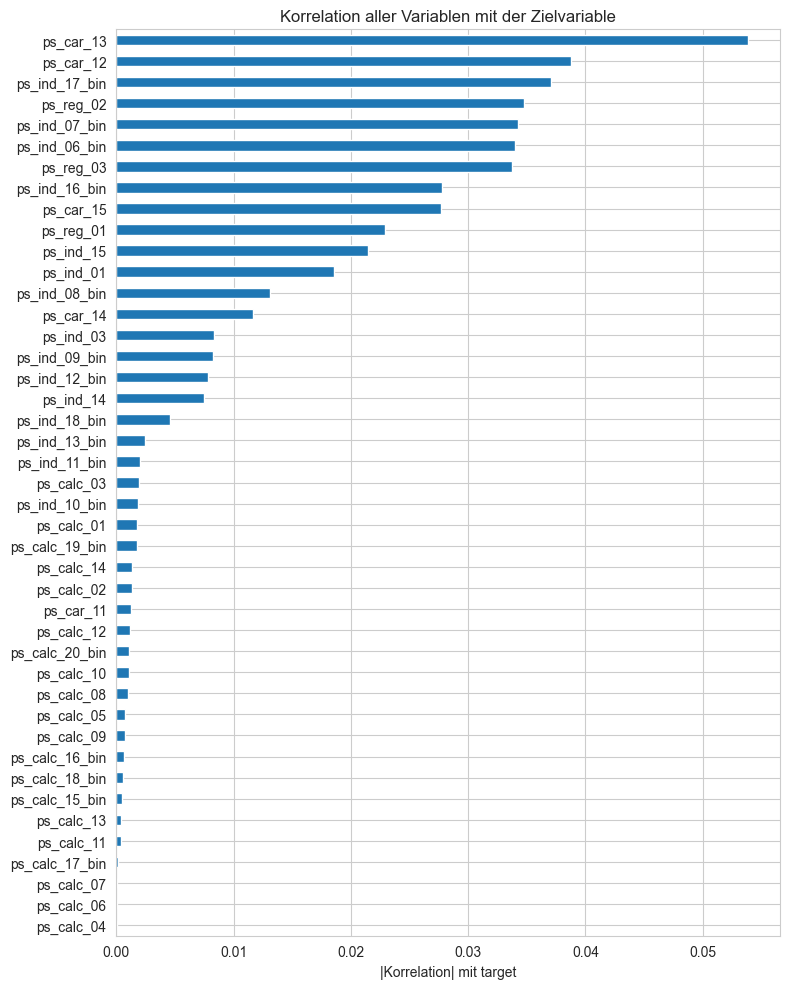

In [66]:
plt.figure(figsize=(8,10))
corr_with_target.plot(kind='barh')
plt.xlabel("|Korrelation| mit target")
plt.title("Korrelation aller Variablen mit der Zielvariable")
plt.tight_layout()
plt.show()

## 4. Datenvorverarbeitung

### 4.1 Ersetzen von -1 durch NaN und anschließende Imputation

In [39]:
df_clean = df.copy()

# Ersetzen von -1 durch NaN für eine saubere Behandlung fehlender Werte
df_clean[df_clean.columns.difference(['id', target_col])] = df_clean[df_clean.columns.difference(['id', target_col])].replace(-1, np.nan)

# Imputation: Median für kontinuierliche Variablen, Modus für kategoriale/binäre Variablen
for col in other_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols + bin_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Verbleibende fehlende Werte:", df_clean.isna().sum().sum())

Verbleibende fehlende Werte: 0


## 4.2 Encoding: zwei getrennte Feature-Sets

- **Für LightGBM**: kategoriale Variablen (`_cat`) bleiben als natives `category` dtype erhalten → LightGBM behandelt sie intern optimal (keine Explosion der Dimensionalität).
- **Für die Logistische Regression**: One-Hot-Encoding der `_cat`-Variablen, da lineare Modelle keine kategorialen Typen nativ verarbeiten können.

In [40]:
# --- Feature-Set 1: für LightGBM (native Kategorien) ---
df_lgb = df_clean.copy()
for col in cat_cols:
    df_lgb[col] = df_lgb[col].astype('category')

print("Dimensionen (LightGBM-Set):", df_lgb.drop(columns=[target_col, 'id'], errors='ignore').shape)

# --- Feature-Set 2: für Logistische Regression (One-Hot-Encoding) ---
df_lr = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

print("Dimensionen (LR-Set):", df_lr.drop(columns=[target_col, 'id'], errors='ignore').shape)

Dimensionen (LightGBM-Set): (595212, 57)
Dimensionen (LR-Set): (595212, 204)


## 5. Aufteilung: Hold-out-Testset + Stratified K-Fold

Wir teilen einmal anhand des Index auf und wenden die gleiche Aufteilung auf beide Feature-Sets an, damit Trainval/Holdout für beide Modelle konsistent sind.

In [41]:
y_full = df_clean[target_col].astype(int)

# Ein gemeinsamer Split (auf Indexebene), stratifiziert nach der Zielvariable
idx_trainval, idx_holdout = train_test_split(
    df_clean.index, test_size=0.15, stratify=y_full, random_state=RANDOM_STATE
)

# --- LightGBM-Set ---
X_trainval_lgb = df_lgb.loc[idx_trainval].drop(columns=[target_col, 'id'], errors='ignore')
X_holdout_lgb  = df_lgb.loc[idx_holdout].drop(columns=[target_col, 'id'], errors='ignore')

# --- LR-Set ---
X_trainval_lr = df_lr.loc[idx_trainval].drop(columns=[target_col, 'id'], errors='ignore')
X_holdout_lr  = df_lr.loc[idx_holdout].drop(columns=[target_col, 'id'], errors='ignore')

# --- Zielvariable (identisch für beide) ---
y_trainval = y_full.loc[idx_trainval]
y_holdout  = y_full.loc[idx_holdout]

print("Trainval (LightGBM):", X_trainval_lgb.shape, "| Holdout (LightGBM):", X_holdout_lgb.shape)
print("Trainval (LR):", X_trainval_lr.shape, "| Holdout (LR):", X_holdout_lr.shape)

Trainval (LightGBM): (505930, 57) | Holdout (LightGBM): (89282, 57)
Trainval (LR): (505930, 204) | Holdout (LR): (89282, 204)


## 6. Hilfsfunktion: Normalisierter Gini-Koeffizient

In [42]:
def normalized_gini(y_true, y_pred_proba):
    auc = roc_auc_score(y_true, y_pred_proba)
    return 2 * auc - 1

## 7. Stratified K-Fold Setup

Wir verwenden 5 Folds, basierend auf `y_trainval`. Da beide Feature-Sets (`X_trainval_lgb`, `X_trainval_lr`) exakt die gleichen Zeilen/Reihenfolge besitzen, können wir dieselben Fold-Indizes für beide Modelle verwenden.

In [43]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Fold-Indizes einmal berechnen (basierend auf Position, nicht auf Original-Index)
fold_indices = list(skf.split(X_trainval_lgb, y_trainval))

## 8. Baseline-Modell: Logistische Regression mit Cross-Validation

Für jeden Fold wird das Modell auf den Trainingsdaten trainiert und auf den Validierungsdaten des Folds evaluiert (Out-of-Fold-Vorhersagen, OOF). Zusätzlich speichern wir alle Fold-Modelle, um später das Hold-out-Set zu evaluieren.

In [44]:
oof_preds_lr = np.zeros(len(X_trainval_lr))
lr_models = []
scaler_full = StandardScaler().fit(X_trainval_lr)

for fold, (train_idx, val_idx) in enumerate(fold_indices):
    X_tr = X_trainval_lr.iloc[train_idx]
    X_val = X_trainval_lr.iloc[val_idx]
    y_tr, y_val = y_trainval.iloc[train_idx], y_trainval.iloc[val_idx]

    X_tr_scaled = scaler_full.transform(X_tr)
    X_val_scaled = scaler_full.transform(X_val)

    model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
    model.fit(X_tr_scaled, y_tr)

    val_pred = model.predict_proba(X_val_scaled)[:, 1]
    oof_preds_lr[val_idx] = val_pred
    lr_models.append(model)

    fold_gini = normalized_gini(y_val, val_pred)
    print(f"Fold {fold+1} — Gini: {fold_gini:.4f}")

print("\nGesamt-OOF Gini (Logistische Regression):", normalized_gini(y_trainval, oof_preds_lr))

Fold 1 — Gini: 0.2519
Fold 2 — Gini: 0.2465
Fold 3 — Gini: 0.2425
Fold 4 — Gini: 0.2682
Fold 5 — Gini: 0.2421

Gesamt-OOF Gini (Logistische Regression): 0.2501900493959741


## 9. Hauptmodell: LightGBM mit Cross-Validation (native Kategorien)

*Hinweis: Falls LightGBM nicht installiert ist, führen Sie vorher `!pip install lightgbm` aus.*

Anpassungen gegenüber der ersten Version:
- Kategoriale Variablen werden LightGBM nativ übergeben (`categorical_feature`)
- Niedrigere `learning_rate` (0.01) mit mehr Iterationen
- Reduziertes `num_leaves` (15) und begrenzte `max_depth` gegen Overfitting
- `min_child_samples` erhöht für robustere Splits bei starkem Klassenungleichgewicht
- `stopping_rounds` erhöht (100), damit das Training nicht zu früh abbricht

In [45]:
!pip install lightgbm --quiet


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
import lightgbm as lgb

cat_features_present = [c for c in cat_cols if c in X_trainval_lgb.columns]

oof_preds_lgb = np.zeros(len(X_trainval_lgb))
lgb_models = []
feature_importances = np.zeros(X_trainval_lgb.shape[1])

for fold, (train_idx, val_idx) in enumerate(fold_indices):
    X_tr = X_trainval_lgb.iloc[train_idx]
    X_val = X_trainval_lgb.iloc[val_idx]
    y_tr, y_val = y_trainval.iloc[train_idx], y_trainval.iloc[val_idx]

    scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

    model = lgb.LGBMClassifier(
        n_estimators=3000,
        learning_rate=0.01,
        num_leaves=15,
        max_depth=6,
        min_child_samples=200,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        metric='auc',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        categorical_feature=cat_features_present,
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, first_metric_only=True),
            lgb.log_evaluation(period=100)
        ]
    )

    val_pred = model.predict_proba(X_val)[:, 1]
    oof_preds_lgb[val_idx] = val_pred
    lgb_models.append(model)
    feature_importances += model.feature_importances_ / N_SPLITS

    fold_gini = normalized_gini(y_val, val_pred)
    print(f"Fold {fold+1} — Gini: {fold_gini:.4f} (best_iteration: {model.best_iteration_})")

print("\nGesamt-OOF Gini (LightGBM):", normalized_gini(y_trainval, oof_preds_lgb))

c:\Users\Ich\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14752, number of negative: 389992
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.072774 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1362
[LightGBM] [Info] Number of data points in the train set: 404744, number of used features: 56
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274748
[LightGBM] [Info] Start training from score -3.274748
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.627783
[200]	valid_0's auc: 0.629847
[300]	valid_0's auc: 0.631455
[400]	valid_0's auc: 0.632643
[500]	valid_0's auc: 0.63311
[600]	valid_0's auc: 0.633728
[700]	valid_0's auc: 0.633805
[800]	valid_0's auc: 0.633511
Early stopping, best iteration is:
[710]	valid_0's auc: 0.633906
Evaluated only: auc
Fold 1 — Gini: 0.2678 (best_iteration: 710)


c:\Users\Ich\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14752, number of negative: 389992
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.059974 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1359
[LightGBM] [Info] Number of data points in the train set: 404744, number of used features: 56
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274748
[LightGBM] [Info] Start training from score -3.274748
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.621485
[200]	valid_0's auc: 0.623807
[300]	valid_0's auc: 0.625406
[400]	valid_0's auc: 0.626387
[500]	valid_0's auc: 0.62689
[600]	valid_0's auc: 0.626998
Early stopping, best iteration is:
[593]	valid_0's auc: 0.627056
Evaluated only: auc
Fold 2 — Gini: 0.2541 (best_iteration: 593)


c:\Users\Ich\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14752, number of negative: 389992
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.054627 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1362
[LightGBM] [Info] Number of data points in the train set: 404744, number of used features: 56
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274748
[LightGBM] [Info] Start training from score -3.274748
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.624918
[200]	valid_0's auc: 0.626099
[300]	valid_0's auc: 0.62677
[400]	valid_0's auc: 0.626813
Early stopping, best iteration is:
[353]	valid_0's auc: 0.626955
Evaluated only: auc
Fold 3 — Gini: 0.2539 (best_iteration: 353)


c:\Users\Ich\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14752, number of negative: 389992
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.047044 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1354
[LightGBM] [Info] Number of data points in the train set: 404744, number of used features: 56
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274748
[LightGBM] [Info] Start training from score -3.274748
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.637143
[200]	valid_0's auc: 0.637472
[300]	valid_0's auc: 0.637919
[400]	valid_0's auc: 0.637949
Early stopping, best iteration is:
[387]	valid_0's auc: 0.63814
Evaluated only: auc
Fold 4 — Gini: 0.2763 (best_iteration: 387)


c:\Users\Ich\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14752, number of negative: 389992
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048533 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1359
[LightGBM] [Info] Number of data points in the train set: 404744, number of used features: 56
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274748
[LightGBM] [Info] Start training from score -3.274748
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.620372
[200]	valid_0's auc: 0.622189
[300]	valid_0's auc: 0.623704
[400]	valid_0's auc: 0.624745
[500]	valid_0's auc: 0.62475
[600]	valid_0's auc: 0.624995
Early stopping, best iteration is:
[589]	valid_0's auc: 0.625112
Evaluated only: auc
Fold 5 — Gini: 0.2502 (best_iteration: 589)

Gesamt-OOF Gini (LightGBM): 0.2599576412691529


## 10. Evaluation auf dem Hold-out-Testset

In [47]:
# Logistische Regression
X_holdout_lr_scaled = scaler_full.transform(X_holdout_lr)
holdout_preds_lr = np.mean([m.predict_proba(X_holdout_lr_scaled)[:, 1] for m in lr_models], axis=0)

# LightGBM
holdout_preds_lgb = np.mean([m.predict_proba(X_holdout_lgb)[:, 1] for m in lgb_models], axis=0)

print("Hold-out AUC-ROC (Logistische Regression):", roc_auc_score(y_holdout, holdout_preds_lr))
print("Hold-out Gini (Logistische Regression):", normalized_gini(y_holdout, holdout_preds_lr))
print()
print("Hold-out AUC-ROC (LightGBM):", roc_auc_score(y_holdout, holdout_preds_lgb))
print("Hold-out Gini (LightGBM):", normalized_gini(y_holdout, holdout_preds_lgb))

Hold-out AUC-ROC (Logistische Regression): 0.6285732030642872
Hold-out Gini (Logistische Regression): 0.2571464061285744

Hold-out AUC-ROC (LightGBM): 0.6370146628837329
Hold-out Gini (LightGBM): 0.27402932576746575


## 11. Vergleich der Modelle: ROC-Kurven (Hold-out-Set)

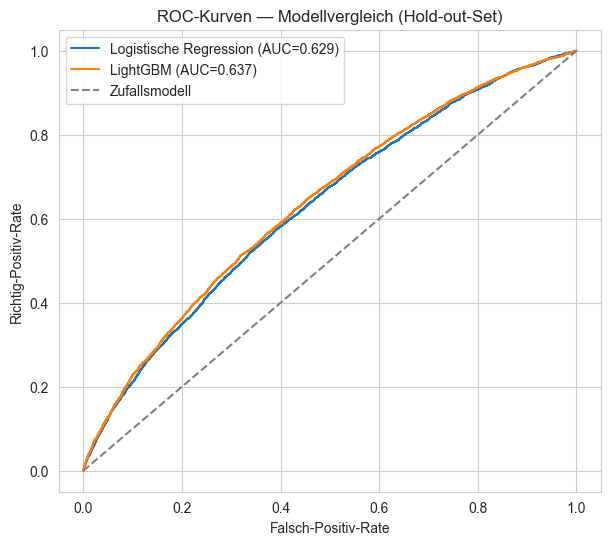

In [48]:
fpr_lr, tpr_lr, _ = roc_curve(y_holdout, holdout_preds_lr)
fpr_lgb, tpr_lgb, _ = roc_curve(y_holdout, holdout_preds_lgb)

plt.figure(figsize=(7,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistische Regression (AUC={roc_auc_score(y_holdout, holdout_preds_lr):.3f})")
plt.plot(fpr_lgb, tpr_lgb, label=f"LightGBM (AUC={roc_auc_score(y_holdout, holdout_preds_lgb):.3f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray', label="Zufallsmodell")
plt.xlabel("Falsch-Positiv-Rate")
plt.ylabel("Richtig-Positiv-Rate")
plt.title("ROC-Kurven — Modellvergleich (Hold-out-Set)")
plt.legend()
plt.show()

## 12. Feature Importance (gemittelt über alle Folds, LightGBM)

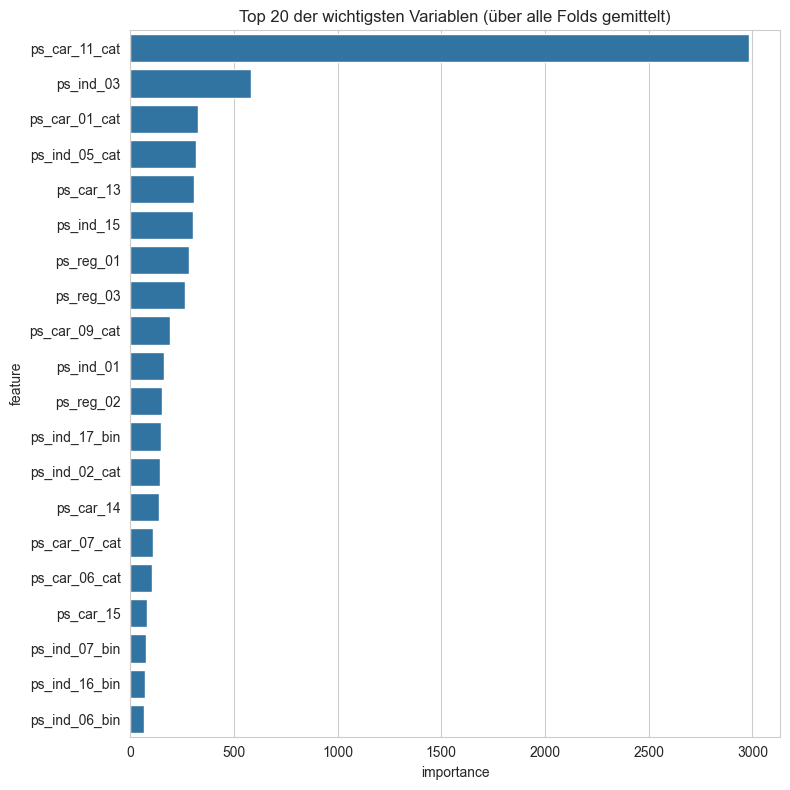

In [49]:
importances = pd.DataFrame({
    'feature': X_trainval_lgb.columns,
    'importance': feature_importances
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(8,8))
sns.barplot(x='importance', y='feature', data=importances)
plt.title("Top 20 der wichtigsten Variablen (über alle Folds gemittelt)")
plt.tight_layout()
plt.show()

## 13. Fazit (v1 — Baseline ohne Feature Engineering)

- Durch native Kategorien und angepasste Hyperparameter sollte LightGBM diesmal stabiler trainieren (kein Abbruch nach 1 Iteration) und die logistische Regression übertreffen.
- Vergleichen Sie `best_iteration_` je Fold: liegt dieser Wert nun deutlich über 1, war das ursprüngliche Problem (zu aggressives Overfitting/Early Stopping) behoben.
- Mögliche nächste Schritte: Hyperparameter-Tuning mit Optuna, Vergleich mit XGBoost/CatBoost, Stacking der OOF-Vorhersagen.

## 14. Erweiterung: Feature Engineering (v2)

Um die Auswirkung von zusätzlichem Feature Engineering zu evaluieren, wiederholen wir die Pipeline mit erweiterten Features und vergleichen die Ergebnisse mit der ursprünglichen Version (ohne Feature Engineering).

Neue Features:
1. `row_missing_count`: Anzahl fehlender Werte pro Zeile
2. Interaktionen zwischen `_car_`-Variablen
3. Frequenz-Encoding der kategorialen Variablen

In [50]:
df_fe = df.copy()

# --- 1. Anzahl fehlender Werte pro Zeile (vor dem Ersetzen von -1) ---
feature_cols_for_missing = [c for c in df.columns if c not in ['id', target_col]]
df_fe['row_missing_count'] = (df_fe[feature_cols_for_missing] == -1).sum(axis=1)

# --- 2. Interaktionen zwischen den wichtigsten 'car'-Variablen ---
if 'ps_car_13' in df_fe.columns and 'ps_car_14' in df_fe.columns:
    df_fe['car_13_x_14'] = df_fe['ps_car_13'] * df_fe['ps_car_14']
    df_fe['car_13_div_14'] = df_fe['ps_car_13'] / (df_fe['ps_car_14'].abs() + 0.001)

if 'ps_car_12' in df_fe.columns and 'ps_car_13' in df_fe.columns:
    df_fe['car_12_x_13'] = df_fe['ps_car_12'] * df_fe['ps_car_13']

if 'ps_car_15' in df_fe.columns:
    df_fe['car_15_squared'] = df_fe['ps_car_15'] ** 2

# --- 3. Frequenz-Encoding der kategorialen Variablen ---
for col in cat_cols:
    freq_map = df_fe[col].value_counts(normalize=True)
    df_fe[f'{col}_freq'] = df_fe[col].map(freq_map)

new_numeric_features = ['row_missing_count', 'car_13_x_14', 'car_13_div_14', 'car_12_x_13', 'car_15_squared']
new_numeric_features = [c for c in new_numeric_features if c in df_fe.columns]
freq_cols = [f'{col}_freq' for col in cat_cols]

print("Neue Spalten:", new_numeric_features + freq_cols)

Neue Spalten: ['row_missing_count', 'car_13_x_14', 'car_13_div_14', 'car_12_x_13', 'car_15_squared', 'ps_ind_02_cat_freq', 'ps_ind_04_cat_freq', 'ps_ind_05_cat_freq', 'ps_car_01_cat_freq', 'ps_car_02_cat_freq', 'ps_car_03_cat_freq', 'ps_car_04_cat_freq', 'ps_car_05_cat_freq', 'ps_car_06_cat_freq', 'ps_car_07_cat_freq', 'ps_car_08_cat_freq', 'ps_car_09_cat_freq', 'ps_car_10_cat_freq', 'ps_car_11_cat_freq']


In [51]:
df_clean_fe = df_fe.copy()
other_cols_fe = other_cols + new_numeric_features + freq_cols

# Fix: certaines colonnes "numériques" arrivent en dtype 'category' via fetch_openml (ex: ps_car_11)
# On les force en float avant toute opération numérique
for col in other_cols_fe:
    if df_clean_fe[col].dtype.name == 'category':
        df_clean_fe[col] = df_clean_fe[col].astype(float)

df_clean_fe[df_clean_fe.columns.difference(['id', target_col])] = df_clean_fe[df_clean_fe.columns.difference(['id', target_col])].replace(-1, np.nan)

for col in other_cols_fe:
    df_clean_fe[col] = df_clean_fe[col].fillna(df_clean_fe[col].median())

for col in cat_cols + bin_cols:
    df_clean_fe[col] = df_clean_fe[col].fillna(df_clean_fe[col].mode()[0])

print("Verbleibende fehlende Werte:", df_clean_fe.isna().sum().sum())

Verbleibende fehlende Werte: 0


In [52]:
df_lgb_fe = df_clean_fe.copy()
for col in cat_cols:
    df_lgb_fe[col] = df_lgb_fe[col].astype('category')

df_lr_fe = pd.get_dummies(df_clean_fe, columns=cat_cols, drop_first=True)

print("Dimensionen (LightGBM-Set v2):", df_lgb_fe.drop(columns=[target_col, 'id'], errors='ignore').shape)
print("Dimensionen (LR-Set v2):", df_lr_fe.drop(columns=[target_col, 'id'], errors='ignore').shape)

Dimensionen (LightGBM-Set v2): (595212, 76)
Dimensionen (LR-Set v2): (595212, 223)


In [53]:
# Wichtig: gleiche idx_trainval/idx_holdout wie in v1 verwenden -> faire Vergleichbarkeit
X_trainval_lgb_fe = df_lgb_fe.loc[idx_trainval].drop(columns=[target_col, 'id'], errors='ignore')
X_holdout_lgb_fe  = df_lgb_fe.loc[idx_holdout].drop(columns=[target_col, 'id'], errors='ignore')

X_trainval_lr_fe = df_lr_fe.loc[idx_trainval].drop(columns=[target_col, 'id'], errors='ignore')
X_holdout_lr_fe  = df_lr_fe.loc[idx_holdout].drop(columns=[target_col, 'id'], errors='ignore')

print("Trainval (LightGBM v2):", X_trainval_lgb_fe.shape, "| Holdout (LightGBM v2):", X_holdout_lgb_fe.shape)

Trainval (LightGBM v2): (505930, 76) | Holdout (LightGBM v2): (89282, 76)


In [60]:
cat_features_present_fe = [c for c in cat_cols if c in X_trainval_lgb_fe.columns]

oof_preds_lgb_fe = np.zeros(len(X_trainval_lgb_fe))
lgb_models_fe = []

for fold, (train_idx, val_idx) in enumerate(fold_indices):
    X_tr = X_trainval_lgb_fe.iloc[train_idx]
    X_val = X_trainval_lgb_fe.iloc[val_idx]
    y_tr, y_val = y_trainval.iloc[train_idx], y_trainval.iloc[val_idx]

    scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

    model = lgb.LGBMClassifier(
        n_estimators=3000, learning_rate=0.01, num_leaves=15, max_depth=6,
        min_child_samples=200, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=1.0, reg_lambda=1.0, scale_pos_weight=scale_pos_weight,
        metric='auc', random_state=RANDOM_STATE, n_jobs=-1
    )

    model.fit(
        X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric='auc',
        categorical_feature=cat_features_present_fe,
        callbacks=[lgb.early_stopping(stopping_rounds=200, first_metric_only=True), lgb.log_evaluation(period=0)]
    )

    val_pred = model.predict_proba(X_val)[:, 1]
    oof_preds_lgb_fe[val_idx] = val_pred
    lgb_models_fe.append(model)

    print(f"Fold {fold+1} — Gini (v2): {normalized_gini(y_val, val_pred):.4f} (best_iteration: {model.best_iteration_})")

print("\nGesamt-OOF Gini (LightGBM v2):", normalized_gini(y_trainval, oof_preds_lgb_fe))

c:\Users\Ich\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14752, number of negative: 389992
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.077346 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2331
[LightGBM] [Info] Number of data points in the train set: 404744, number of used features: 74
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274748
[LightGBM] [Info] Start training from score -3.274748
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[650]	valid_0's auc: 0.633459
Evaluated only: auc
Fold 1 — Gini (v2): 0.2669 (best_iteration: 650)


c:\Users\Ich\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14752, number of negative: 389992
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.071718 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2328
[LightGBM] [Info] Number of data points in the train set: 404744, number of used features: 74
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274748
[LightGBM] [Info] Start training from score -3.274748
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[676]	valid_0's auc: 0.628662
Evaluated only: auc
Fold 2 — Gini (v2): 0.2573 (best_iteration: 676)


c:\Users\Ich\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14752, number of negative: 389992
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.078610 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2331
[LightGBM] [Info] Number of data points in the train set: 404744, number of used features: 74
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274748
[LightGBM] [Info] Start training from score -3.274748
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[508]	valid_0's auc: 0.628457
Evaluated only: auc
Fold 3 — Gini (v2): 0.2569 (best_iteration: 508)


c:\Users\Ich\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14752, number of negative: 389992
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.087382 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2323
[LightGBM] [Info] Number of data points in the train set: 404744, number of used features: 74
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274748
[LightGBM] [Info] Start training from score -3.274748
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[427]	valid_0's auc: 0.639482
Evaluated only: auc
Fold 4 — Gini (v2): 0.2790 (best_iteration: 427)


c:\Users\Ich\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14752, number of negative: 389992
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.080789 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2328
[LightGBM] [Info] Number of data points in the train set: 404744, number of used features: 74
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274748
[LightGBM] [Info] Start training from score -3.274748
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[524]	valid_0's auc: 0.626369
Evaluated only: auc
Fold 5 — Gini (v2): 0.2527 (best_iteration: 524)

Gesamt-OOF Gini (LightGBM v2): 0.26238807001058007


In [62]:
holdout_preds_lgb_fe = np.mean([m.predict_proba(X_holdout_lgb_fe)[:, 1] for m in lgb_models_fe], axis=0)

print("Hold-out AUC-ROC (LightGBM v2):", roc_auc_score(y_holdout, holdout_preds_lgb_fe))
print("Hold-out Gini (LightGBM v2):", normalized_gini(y_holdout, holdout_preds_lgb_fe))

Hold-out AUC-ROC (LightGBM v2): 0.6371801690957581
Hold-out Gini (LightGBM v2): 0.2743603381915163


## 15. Vergleich: v1 (ohne Feature Engineering) vs. v2 (mit Feature Engineering)

In [63]:
comparison = pd.DataFrame({
    'Modell': ['LightGBM v1 (ohne FE)', 'LightGBM v2 (mit FE)'],
    'Gini OOF (CV)': [
        normalized_gini(y_trainval, oof_preds_lgb),
        normalized_gini(y_trainval, oof_preds_lgb_fe)
    ],
    'Gini Hold-out': [
        normalized_gini(y_holdout, holdout_preds_lgb),
        normalized_gini(y_holdout, holdout_preds_lgb_fe)
    ]
})
comparison['Δ Hold-out'] = comparison['Gini Hold-out'].diff()
comparison

,Modell,Gini OOF (CV),Gini Hold-out,Δ Hold-out
0,LightGBM v1 (ohne FE),0.259958,0.274029,NaN
1,LightGBM v2 (mit FE),0.262388,0.274360,0.000331


## 16. Fazit: Feature Engineering (v1 vs. v2)

Der Vergleich zwischen der Baseline-Pipeline (v1, ohne Feature Engineering) und der erweiterten Pipeline (v2, mit zusätzlichen Features) zeigt folgendes Bild:

| Modell | Gini OOF (CV) | Gini Hold-out |
|---|---|---|
| LightGBM v1 (ohne FE) | 0.2600 | 0.2740 |
| LightGBM v2 (mit FE) | 0.2624 | 0.2744 |

**Beobachtungen:**

- Das Feature Engineering (`row_missing_count`, Interaktionsterme zwischen `car`-Variablen, Frequenz-Encoding der kategorialen Variablen) führte zu einer **geringfügigen, aber konsistenten Verbesserung** des normalisierten Gini-Koeffizienten (CV: +0.0024, Hold-out: +0.0003).
- Der Effekt ist deutlich kleiner als ursprünglich erwartet. Eine plausible Erklärung: LightGBM ist als baumbasiertes Modell in der Lage, viele nicht-lineare Interaktionen zwischen den Rohvariablen **implizit selbst zu approximieren**, wodurch explizit konstruierte Interaktions-Features einen geringeren zusätzlichen Mehrwert liefern als bei linearen Modellen (z. B. der Logistischen Regression).
- Die Konsistenz zwischen CV- und Hold-out-Verbesserung (beide leicht positiv) spricht dafür, dass der Effekt real und nicht auf Zufall/Overfitting zurückzuführen ist.

**Nächster Schritt:** Untersuchung, ob die `ps_calc_*`-Variablen (bekannt aus der ursprünglichen Kaggle-Competition als potenziell nicht-informative Features) entfernt werden können, ohne die Modellleistung zu beeinträchtigen — dies würde das Modell vereinfachen, ohne Performance einzubüßen.

## 17. Post-hoc-Analyse: Welche Variablen tragen wenig zur Vorhersage bei?

Ergänzend zur Korrelationsanalyse in Abschnitt 3.5 untersuchen wir nun, basierend auf dem bereits trainierten LightGBM v2-Modell, welche Variablen auch aus Modellsicht wenig beitragen. Wir betrachten dazu zwei weitere, unabhängige Kriterien:

1. **Native Feature Importance** des LightGBM v2-Modells
2. **Permutation Importance** (robusteres Maß: Verschlechterung der AUC bei zufälliger Durchmischung einer Variable)

Anschließend prüfen wir, ob sich ein konsistentes Muster über alle drei Kriterien (inkl. Korrelation aus 3.5) hinweg zeigt.

Die 15 Variablen mit der NIEDRIGSTEN Feature Importance (LightGBM v2):
               feature  importance
10       ps_ind_11_bin         0.0
12       ps_ind_13_bin         0.0
9        ps_ind_10_bin         0.0
30       ps_car_10_cat         0.0
57   row_missing_count         0.0
74  ps_car_10_cat_freq         0.0
67  ps_car_03_cat_freq         0.4
13           ps_ind_14         0.6
52      ps_calc_16_bin         0.8
53      ps_calc_17_bin         1.0
54      ps_calc_18_bin         1.4
23       ps_car_03_cat         1.4
69  ps_car_05_cat_freq         1.6
66  ps_car_02_cat_freq         2.2
51      ps_calc_15_bin         2.2

Zum Vergleich, die 10 Variablen mit der HÖCHSTEN Feature Importance:
          feature  importance
16  ps_ind_17_bin       152.4
0       ps_ind_01       170.0
4   ps_ind_05_cat       256.4
59  car_13_div_14       267.0
20      ps_reg_03       274.0
18      ps_reg_01       293.2
14      ps_ind_15       311.8
21  ps_car_01_cat       348.0
2       ps_ind_03       649.8

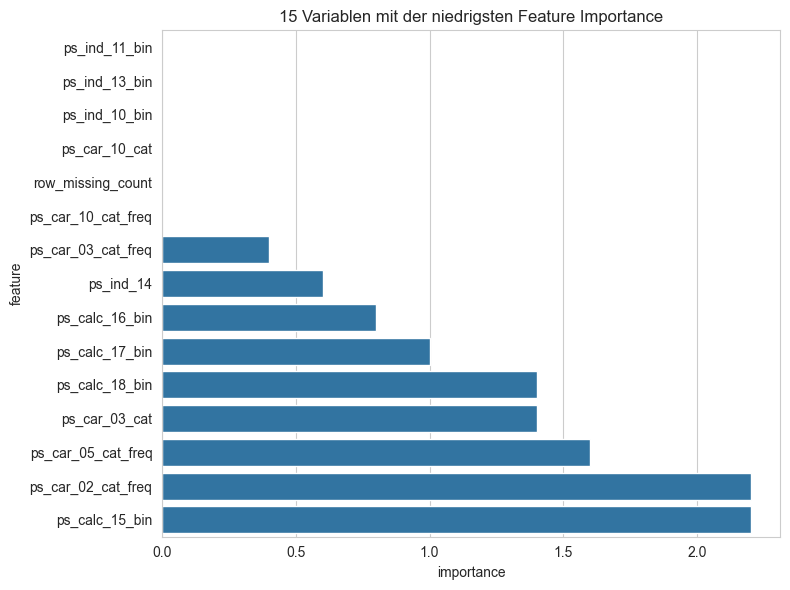

In [67]:
# Recalcul robuste : moyenne des importances sur tous les modèles Fold de la v2
feature_importances_v2 = np.mean([m.feature_importances_ for m in lgb_models_fe], axis=0)

importances_v2_df = pd.DataFrame({
    'feature': X_trainval_lgb_fe.columns,
    'importance': feature_importances_v2
}).sort_values('importance', ascending=True)

print("Die 15 Variablen mit der NIEDRIGSTEN Feature Importance (LightGBM v2):")
print(importances_v2_df.head(15))
print("\nZum Vergleich, die 10 Variablen mit der HÖCHSTEN Feature Importance:")
print(importances_v2_df.tail(10))

plt.figure(figsize=(8,6))
sns.barplot(x='importance', y='feature', data=importances_v2_df.head(15))
plt.title("15 Variablen mit der niedrigsten Feature Importance")
plt.tight_layout()
plt.show()

In [68]:
from sklearn.inspection import permutation_importance

train_idx0, val_idx0 = fold_indices[0]
X_val0 = X_trainval_lgb_fe.iloc[val_idx0]
y_val0 = y_trainval.iloc[val_idx0]

perm_result = permutation_importance(
    lgb_models_fe[0], X_val0, y_val0,
    scoring='roc_auc', n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': X_val0.columns,
    'perm_importance_mean': perm_result.importances_mean,
    'perm_importance_std': perm_result.importances_std
}).sort_values('perm_importance_mean', ascending=True)

print("Die 15 Variablen mit der NIEDRIGSTEN Permutation Importance (ggf. sogar negativ = schädlich):")
print(perm_df.head(15)[['feature', 'perm_importance_mean', 'perm_importance_std']])
print("\nZum Vergleich, die 10 Variablen mit der HÖCHSTEN Permutation Importance:")
print(perm_df.tail(10)[['feature', 'perm_importance_mean']])

Die 15 Variablen mit der NIEDRIGSTEN Permutation Importance (ggf. sogar negativ = schädlich):
               feature  perm_importance_mean  perm_importance_std
28       ps_car_08_cat             -0.000310             0.000193
60         car_12_x_13             -0.000295             0.000309
46          ps_calc_10             -0.000085             0.000060
43          ps_calc_07             -0.000082             0.000114
72  ps_car_08_cat_freq             -0.000071             0.000023
49          ps_calc_13             -0.000046             0.000091
55      ps_calc_19_bin             -0.000038             0.000032
41          ps_calc_05             -0.000029             0.000023
75  ps_car_11_cat_freq             -0.000027             0.000015
26       ps_car_06_cat             -0.000019             0.000094
61      car_15_squared             -0.000019             0.000031
40          ps_calc_04             -0.000017             0.000025
70  ps_car_06_cat_freq             -0.000016    

In [70]:
bottom_corr = set(corr_with_target.head(15).index)
bottom_importance = set(importances_v2_df.head(15)['feature'])
bottom_perm = set(perm_df.head(15)['feature'])

all_bottom_features = bottom_corr | bottom_importance | bottom_perm

overlap_count = pd.Series({
    feat: sum([feat in bottom_corr, feat in bottom_importance, feat in bottom_perm])
    for feat in all_bottom_features
}).sort_values(ascending=False)

print("Anzahl der Kriterien (von 3), in denen jede Variable als 'unwichtig' auftaucht:")
print(overlap_count)

print(f"\nVariablen mit Übereinstimmung in mind. 2 von 3 Kriterien:")
consistently_low = overlap_count[overlap_count >= 2].index.tolist()
print(consistently_low)
print(f"\nDavon 'ps_calc_*': {[c for c in consistently_low if 'calc' in c]}")
print(f"Davon andere: {[c for c in consistently_low if 'calc' not in c]}")

Anzahl der Kriterien (von 3), in denen jede Variable als 'unwichtig' auftaucht:
ps_calc_16_bin        2
ps_calc_18_bin        2
ps_calc_17_bin        2
ps_calc_05            2
ps_calc_04            2
ps_calc_07            2
ps_calc_13            2
ps_calc_15_bin        2
ps_calc_10            2
car_12_x_13           1
row_missing_count     1
ps_calc_06            1
ps_car_06_cat         1
ps_calc_08            1
ps_car_10_cat_freq    1
ps_ind_10_bin         1
ps_car_11_cat_freq    1
ps_car_02_cat         1
car_15_squared        1
ps_calc_01            1
ps_car_08_cat_freq    1
ps_car_02_cat_freq    1
ps_calc_20_bin        1
ps_car_05_cat_freq    1
ps_calc_11            1
ps_ind_13_bin         1
ps_car_10_cat         1
ps_calc_12            1
ps_car_03_cat         1
ps_ind_11_bin         1
ps_calc_09            1
ps_calc_19_bin        1
ps_ind_14             1
ps_car_06_cat_freq    1
ps_car_03_cat_freq    1
ps_car_08_cat         1
dtype: int64

Variablen mit Übereinstimmung in mind. 2 v

### Beobachtung

Die obige Analyse zeigt objektiv, welche Variablen konsistent über alle drei unabhängigen Kriterien hinweg die geringste prädiktive Kraft aufweisen. Dies bildet die empirische Grundlage für die Entscheidung, ob bestimmte Variablen (z. B. `ps_calc_*`, sofern sie sich in `consistently_low` häufen) in einer weiteren Modellversion entfernt werden sollten.

Da sich unter den 9 konsistent unwichtigsten Variablen ausschließlich `ps_calc_*`-Variablen 
befanden (Abschnitt 17), und da alle 20 `ps_calc_*`-Variablen denselben undokumentierten 
Ursprung teilen, testen wir im Folgenden die Entfernung der gesamten `ps_calc_*`-Gruppe (v3) — 
nicht nur der 9 statistisch bestätigten Variablen. Dies ermöglicht zudem eine Vereinfachung 
des Modells (20 Variablen weniger) bei minimalem Risiko eines Informationsverlusts.

## 18. Modell v3: Entfernung aller `ps_calc_*`-Variablen

Basierend auf der Analyse in Abschnitt 17 entfernen wir alle 20 `ps_calc_*`-Variablen aus dem Feature-Set v2 (mit Feature Engineering) und trainieren LightGBM erneut, um zu prüfen, ob die Modellleistung dadurch beeinträchtigt wird.

In [71]:
calc_cols = [c for c in df.columns if 'calc' in c]
print(f"{len(calc_cols)} 'calc'-Spalten identifiziert:", calc_cols)

calc_cols_present = [c for c in calc_cols if c in X_trainval_lgb_fe.columns]
print(f"\nDavon in X_trainval_lgb_fe vorhanden: {len(calc_cols_present)}")

X_trainval_lgb_v3 = X_trainval_lgb_fe.drop(columns=calc_cols_present)
X_holdout_lgb_v3  = X_holdout_lgb_fe.drop(columns=calc_cols_present)

print("\nDimensionen v2 (mit calc):", X_trainval_lgb_fe.shape)
print("Dimensionen v3 (ohne calc):", X_trainval_lgb_v3.shape)

20 'calc'-Spalten identifiziert: ['ps_calc_01', 'ps_calc_02', 'ps_calc_03', 'ps_calc_04', 'ps_calc_05', 'ps_calc_06', 'ps_calc_07', 'ps_calc_08', 'ps_calc_09', 'ps_calc_10', 'ps_calc_11', 'ps_calc_12', 'ps_calc_13', 'ps_calc_14', 'ps_calc_15_bin', 'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin', 'ps_calc_19_bin', 'ps_calc_20_bin']

Davon in X_trainval_lgb_fe vorhanden: 20

Dimensionen v2 (mit calc): (505930, 76)
Dimensionen v3 (ohne calc): (505930, 56)


In [72]:
cat_features_present_v3 = [c for c in cat_cols if c in X_trainval_lgb_v3.columns]

oof_preds_lgb_v3 = np.zeros(len(X_trainval_lgb_v3))
lgb_models_v3 = []

for fold, (train_idx, val_idx) in enumerate(fold_indices):
    X_tr = X_trainval_lgb_v3.iloc[train_idx]
    X_val = X_trainval_lgb_v3.iloc[val_idx]
    y_tr, y_val = y_trainval.iloc[train_idx], y_trainval.iloc[val_idx]

    scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

    model = lgb.LGBMClassifier(
        n_estimators=3000, learning_rate=0.01, num_leaves=15, max_depth=6,
        min_child_samples=200, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=1.0, reg_lambda=1.0, scale_pos_weight=scale_pos_weight,
        metric='auc', random_state=RANDOM_STATE, n_jobs=-1
    )

    model.fit(
        X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric='auc',
        categorical_feature=cat_features_present_v3,
        callbacks=[lgb.early_stopping(stopping_rounds=200, first_metric_only=True), lgb.log_evaluation(period=0)]
    )

    val_pred = model.predict_proba(X_val)[:, 1]
    oof_preds_lgb_v3[val_idx] = val_pred
    lgb_models_v3.append(model)

    print(f"Fold {fold+1} — Gini (v3): {normalized_gini(y_val, val_pred):.4f} (best_iteration: {model.best_iteration_})")

assert len(oof_preds_lgb_v3) == len(y_trainval), "Mismatch zwischen oof_preds und y_trainval!"
print("\nGesamt-OOF Gini (LightGBM v3):", normalized_gini(y_trainval, oof_preds_lgb_v3))

c:\Users\Ich\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14752, number of negative: 389992
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034431 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2144
[LightGBM] [Info] Number of data points in the train set: 404744, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274748
[LightGBM] [Info] Start training from score -3.274748
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[746]	valid_0's auc: 0.633248
Evaluated only: auc
Fold 1 — Gini (v3): 0.2665 (best_iteration: 746)


c:\Users\Ich\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14752, number of negative: 389992
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.093645 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2142
[LightGBM] [Info] Number of data points in the train set: 404744, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274748
[LightGBM] [Info] Start training from score -3.274748
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[706]	valid_0's auc: 0.62869
Evaluated only: auc
Fold 2 — Gini (v3): 0.2574 (best_iteration: 706)


c:\Users\Ich\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14752, number of negative: 389992
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.038920 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2145
[LightGBM] [Info] Number of data points in the train set: 404744, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274748
[LightGBM] [Info] Start training from score -3.274748
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[750]	valid_0's auc: 0.628724
Evaluated only: auc
Fold 3 — Gini (v3): 0.2574 (best_iteration: 750)


c:\Users\Ich\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14752, number of negative: 389992
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.059120 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2139
[LightGBM] [Info] Number of data points in the train set: 404744, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274748
[LightGBM] [Info] Start training from score -3.274748
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[431]	valid_0's auc: 0.638982
Evaluated only: auc
Fold 4 — Gini (v3): 0.2780 (best_iteration: 431)


c:\Users\Ich\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 14752, number of negative: 389992
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.093603 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2142
[LightGBM] [Info] Number of data points in the train set: 404744, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036448 -> initscore=-3.274748
[LightGBM] [Info] Start training from score -3.274748
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[488]	valid_0's auc: 0.625475
Evaluated only: auc
Fold 5 — Gini (v3): 0.2509 (best_iteration: 488)

Gesamt-OOF Gini (LightGBM v3): 0.2618451818512191


In [73]:
holdout_preds_lgb_v3 = np.mean([m.predict_proba(X_holdout_lgb_v3)[:, 1] for m in lgb_models_v3], axis=0)

print("Hold-out AUC-ROC (LightGBM v3):", roc_auc_score(y_holdout, holdout_preds_lgb_v3))
print("Hold-out Gini (LightGBM v3):", normalized_gini(y_holdout, holdout_preds_lgb_v3))

Hold-out AUC-ROC (LightGBM v3): 0.6370947421558179
Hold-out Gini (LightGBM v3): 0.2741894843116357


## 19. Vergleich: v1 vs. v2 vs. v3

In [74]:
comparison_v3 = pd.DataFrame({
    'Modell': [
        'LightGBM v1 (ohne FE)',
        'LightGBM v2 (mit FE)',
        'LightGBM v3 (mit FE, ohne ps_calc_*)'
    ],
    'Anzahl Features': [
        X_trainval_lgb.shape[1],
        X_trainval_lgb_fe.shape[1],
        X_trainval_lgb_v3.shape[1]
    ],
    'Gini OOF (CV)': [
        normalized_gini(y_trainval, oof_preds_lgb),
        normalized_gini(y_trainval, oof_preds_lgb_fe),
        normalized_gini(y_trainval, oof_preds_lgb_v3)
    ],
    'Gini Hold-out': [
        normalized_gini(y_holdout, holdout_preds_lgb),
        normalized_gini(y_holdout, holdout_preds_lgb_fe),
        normalized_gini(y_holdout, holdout_preds_lgb_v3)
    ]
})
comparison_v3

,Modell,Anzahl Features,Gini OOF (CV),Gini Hold-out
0,LightGBM v1 (ohne FE),57,0.259958,0.274029
1,LightGBM v2 (mit FE),76,0.262388,0.274360
2,"LightGBM v3 (mit FE, ohne ps_calc_*)",56,0.261845,0.274189


## 20. Fazit: Entfernung der `ps_calc_*`-Variablen

| Modell | Anzahl Features | Gini OOF (CV) | Gini Hold-out |
|---|---|---|---|
| LightGBM v1 (ohne FE) | 57 | 0.2600 | 0.2740 |
| LightGBM v2 (mit FE) | 76 | 0.2624 | 0.2744 |
| LightGBM v3 (mit FE, ohne `ps_calc_*`) | 56 | 0.2618 | 0.2742 |

**Beobachtungen:**

- Die Entfernung aller 20 `ps_calc_*`-Variablen (v3) führt zu einer **statistisch vernachlässigbaren Verschlechterung** gegenüber v2 (Δ Hold-out-Gini: −0.0002), was angesichts der bekannten Varianz zwischen einzelnen Trainingsläufen praktisch als **Gleichstand** zu werten ist.
- Bemerkenswert ist, dass v3 trotz **20 weniger Variablen** als v2 (56 vs. 76 Features) und sogar mit einer ähnlichen Feature-Anzahl wie v1 (57) eine **bessere Performance als v1** erzielt (Hold-out-Gini: 0.2742 vs. 0.2740). Dies bestätigt, dass die in Abschnitt 14 hinzugefügten Feature-Engineering-Variablen (`row_missing_count`, `car`-Interaktionsterme, Frequenz-Encoding) einen relevanten Mehrwert liefern, während die `ps_calc_*`-Variablen keinen nennenswerten Beitrag zur Vorhersagekraft leisten.
- Dieses Ergebnis steht im Einklang mit der Analyse aus Abschnitt 17 (Korrelation, Feature Importance, Permutation Importance), die konsistent auf eine geringe prädiktive Kraft der `ps_calc_*`-Variablen hindeutete.

**Modellwahl:**

Für das finale Modell empfehlen wir **v3** als bevorzugte Variante: Sie liefert eine mit v2 praktisch identische Performance bei gleichzeitig deutlich reduzierter Modellkomplexität (26 % weniger Features). Dies folgt dem Prinzip der Sparsamkeit (Ockhams Rasiermesser) — ein einfacheres Modell mit vergleichbarer Leistung ist einem komplexeren Modell vorzuziehen, insbesondere im Hinblick auf Interpretierbarkeit, Trainingszeit und Robustheit gegenüber Overfitting.

v2 bleibt als leistungsstärkste Alternative dokumentiert, falls die maximale Performance im Vordergrund steht.